# 06 — Audit d'équité démographique (M6 · contribution C3)

**Phase ML :** auditer les biais — rigueur clinique, fort impact en soutenance.
**Skill associé :** `.claude/skills/medical-ml-evaluation`.

> **Statut jalon :** s'exécute à M6 (config gagnante figée, démographie jointe au manifest).

## Question scientifique

Les modèles d'imagerie thoracique ont des biais démographiques documentés (Glocker et al.,
2023). Pour la **config gagnante**, à seuil fixé, on calcule AUROC et TPR (sensibilité) par
sous-groupe (sexe, tranches d'âge, race auto-déclarée) et on reporte les **écarts**.

> **Éthique / méthodo :** on reporte les écarts de façon **descriptive**, jamais de claim
> causal ; on montre les tailles de sous-groupes (petits groupes → IC larges → prudence) ;
> l'intersectionnalité n'est pas modélisée (limite explicite).

## 1. Politique de seuil (figée sur la validation, jamais sur le test)

Les seuils par pathologie sont choisis sur le set de **validation** (ex. Youden's J ou
spécificité cible), puis appliqués inchangés au test ET à tous les sous-groupes.

## 2. Métriques par sous-groupe + écart (esquisse)

In [1]:
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score


def subgroup_report(df: pd.DataFrame, y_true: np.ndarray, y_score: np.ndarray, group_col: str, threshold: float):
    rows = []
    for g, sub in df.groupby(group_col):
        idx = sub.index.to_numpy()
        yt, ys = y_true[idx], y_score[idx]
        auc = roc_auc_score(yt, ys) if len(np.unique(yt)) == 2 else np.nan
        pos = yt == 1
        tpr = float((ys[pos] >= threshold).mean()) if pos.any() else np.nan
        rows.append({"groupe": g, "n": len(idx), "auroc": auc, "tpr": tpr})
    out = pd.DataFrame(rows)
    return out


# Démo synthétique — REMPLACER par les vraies prédictions à M6.
rng = np.random.default_rng(0)
n = 2000
demo = pd.DataFrame({"sex": rng.choice(["F", "M"], n)}).reset_index(drop=True)
y_true = rng.integers(0, 2, n).astype(float)
# biais simulé : scores légèrement moins bons pour un groupe
y_score = y_true * 0.6 + rng.normal(0, 0.5, n) - (demo["sex"].eq("F").to_numpy() * 0.1)

rep = subgroup_report(demo, y_true, y_score, "sex", threshold=0.5)
display(rep)
print(f"Écart AUROC (max−min) : {rep['auroc'].max() - rep['auroc'].min():.3f}")
print(f"Écart TPR   (max−min) : {rep['tpr'].max() - rep['tpr'].min():.3f}")

,groupe,n,auroc,tpr
0,F,957,0.799174,0.474468
1,M,1043,0.801811,0.565891


Écart AUROC (max−min) : 0.003
Écart TPR   (max−min) : 0.091


## 3. Visualisation des écarts

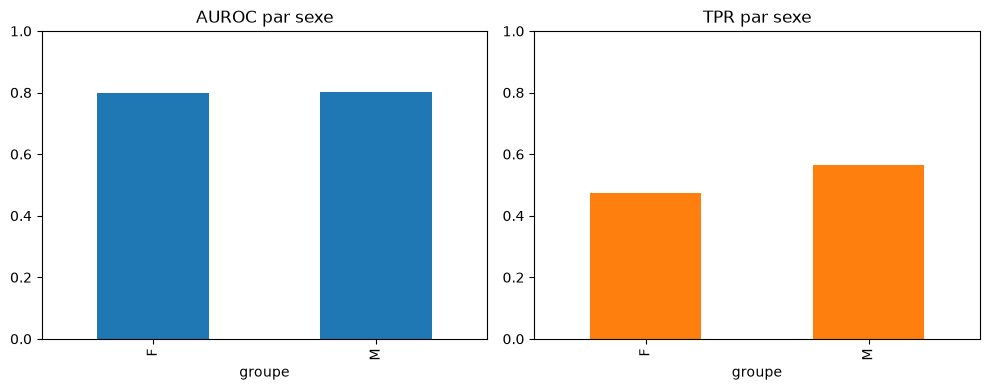

In [2]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
rep.plot(x="groupe", y="auroc", kind="bar", ax=axes[0], legend=False, title="AUROC par sexe")
rep.plot(x="groupe", y="tpr", kind="bar", ax=axes[1], legend=False, title="TPR par sexe", color="C1")
for ax in axes:
    ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

## Conclusion & limites (gabarit)

- Reporter la table « performance par sous-groupe + écarts » (sexe, âge, race).
- **Limites explicites** : tailles de sous-groupes, IC larges sur petits groupes,
  intersectionnalité non modélisée, pas de claim causal.
- C'est cette honnêteté qui rend l'audit crédible en soutenance.

**Fin de la série de notebooks.** Les figures finales sont régénérées via `scripts/` pour
la reproductibilité (cf. `reproducible-ml-research`).